## 0. Libraries

In [1]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [2]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']
colors_02 = ['#332288', '#117733', '#DDCC77', '#882255', '#AA4499', '#88CCEE', '#44AA99', '#999933', '#CC6677', '#DDDDDD']

## 2. Main reproduction

#### **Example 3: Model of complex formation with activation-deactivation cycle**

The model of complex formation with activation-deactivation cycle has also been investigated in [4]. It is composed of the basic model of complex formation in that A
and B bind to form complex AB as described in section 1.2, together with an activation and deactivation of one of the complex-forming species, B and B∗. In addition
to the two reactions of complex formation and complex decomposition, the activating
reaction and the deactivation reaction are modelled using Michaelis-Menten reaction
kinetics. Thereby, the activation of B to B∗
is in addition stimulus-dependent (the
stimulus is modelled as a parameter, kn3), while the deactivation of B∗
to B depends
linearly on species A. The model contains four species, A, B, AB, B∗
, four rate coefficients, k1 . . . , k4, two activation constants, kn1, kn2, and a stimulus parameter, kn3.

$$
\begin{aligned}
\frac{dA}{dt} &= -k_1\,A\,B + k_2\,AB ,\\[6pt]
\frac{dB}{dt} &= -k_1\,A\,B + k_2\,AB + k_3\,A\,\frac{B^*}{B^* + kn_1} - k_4\,kn_3\,\frac{B}{B + kn_2} ,\\[6pt]
\frac{d(AB)}{dt} &= k_1\,A\,B - k_2\,AB ,\\[6pt]
\frac{dB^*}{dt} &= -k_3\,A\,\frac{B^*}{B^* + kn_1} + k_4\,kn_3\,\frac{B}{B + kn_2} .
\end{aligned}
$$

We employed the following parameter set for the analyses: k1 = 0.021458, k2 =
0.000227335, k3 = 663.297, k4 = 0.000139797, kn1 = 55.5913, kn2 = 10.2194, and
values for the stimulus of kn3 = 1 (unstimulated) or kn3 = 20 (stimulated). The initial
conditions were set as A = 5, B = 300, AB = 0.0001, B∗ = 0.01.



In [3]:
def model_complex_formation_act_deact_cycle(y, params):
    A = y[0]
    B = y[1]
    AB = y[2]
    B_star = y[3]
    k1, k2, k3, k4, kn1, kn2, kn3 = params
    dAdt = -k1 * A * B + k2 * AB
    dBdt = -k1 * A * B + k2 * AB + k3 * A * (B_star / (B_star + kn1)) - k4 * kn3 * (B / (B + kn2))
    dABdt = k1 * A * B - k2 * AB
    dB_stardt = -k3 * A * (B_star / (B_star + kn1)) + k4 * kn3 * (B / (B + kn2))
    return np.array([dAdt, dBdt, dABdt, dB_stardt], dtype=float)

def solve_complex_formation_act_deact_cycle(initial_conditions, time_points, params):
    def model(t, x):
        return model_complex_formation_act_deact_cycle(x, params)
    sol = solve_ivp(model, [time_points[0], time_points[-1]], initial_conditions,
                    t_eval=time_points, method='RK45', rtol=1e-6)
    return sol

In [4]:
# Parameters from supplementary material
initial_conditions_act_deact = [5, 300, 0.0001, 0.01]  # Initial concentrations of A, B, AB, and B*
k1 = 0.021458   # Rate constant for complex formation
k2 = 0.000227335   # Rate constant for complex dissociation
k3 = 663.297   # Rate constant for activation
k4 = 0.000139797   # Rate constant for deactivation
kn1 = 55.5913  # Michaelis constant for activation
kn2 = 10.2194  # Michaelis constant for deactivation
kn3_unstimulated = 1.0  # Scaling factor for deactivation under unstimulated conditions
kn3_stimulated = 20.0    # Scaling factor for deactivation under stimulation
params_act_deact_unstimulated = [k1, k2, k3, k4, kn1, kn2, kn3_unstimulated]
params_act_deact_stimulated = [k1, k2, k3, k4, kn1, kn2, kn3_stimulated]

# Parameters not yet in supplement data
# perturbation_point = 0.2

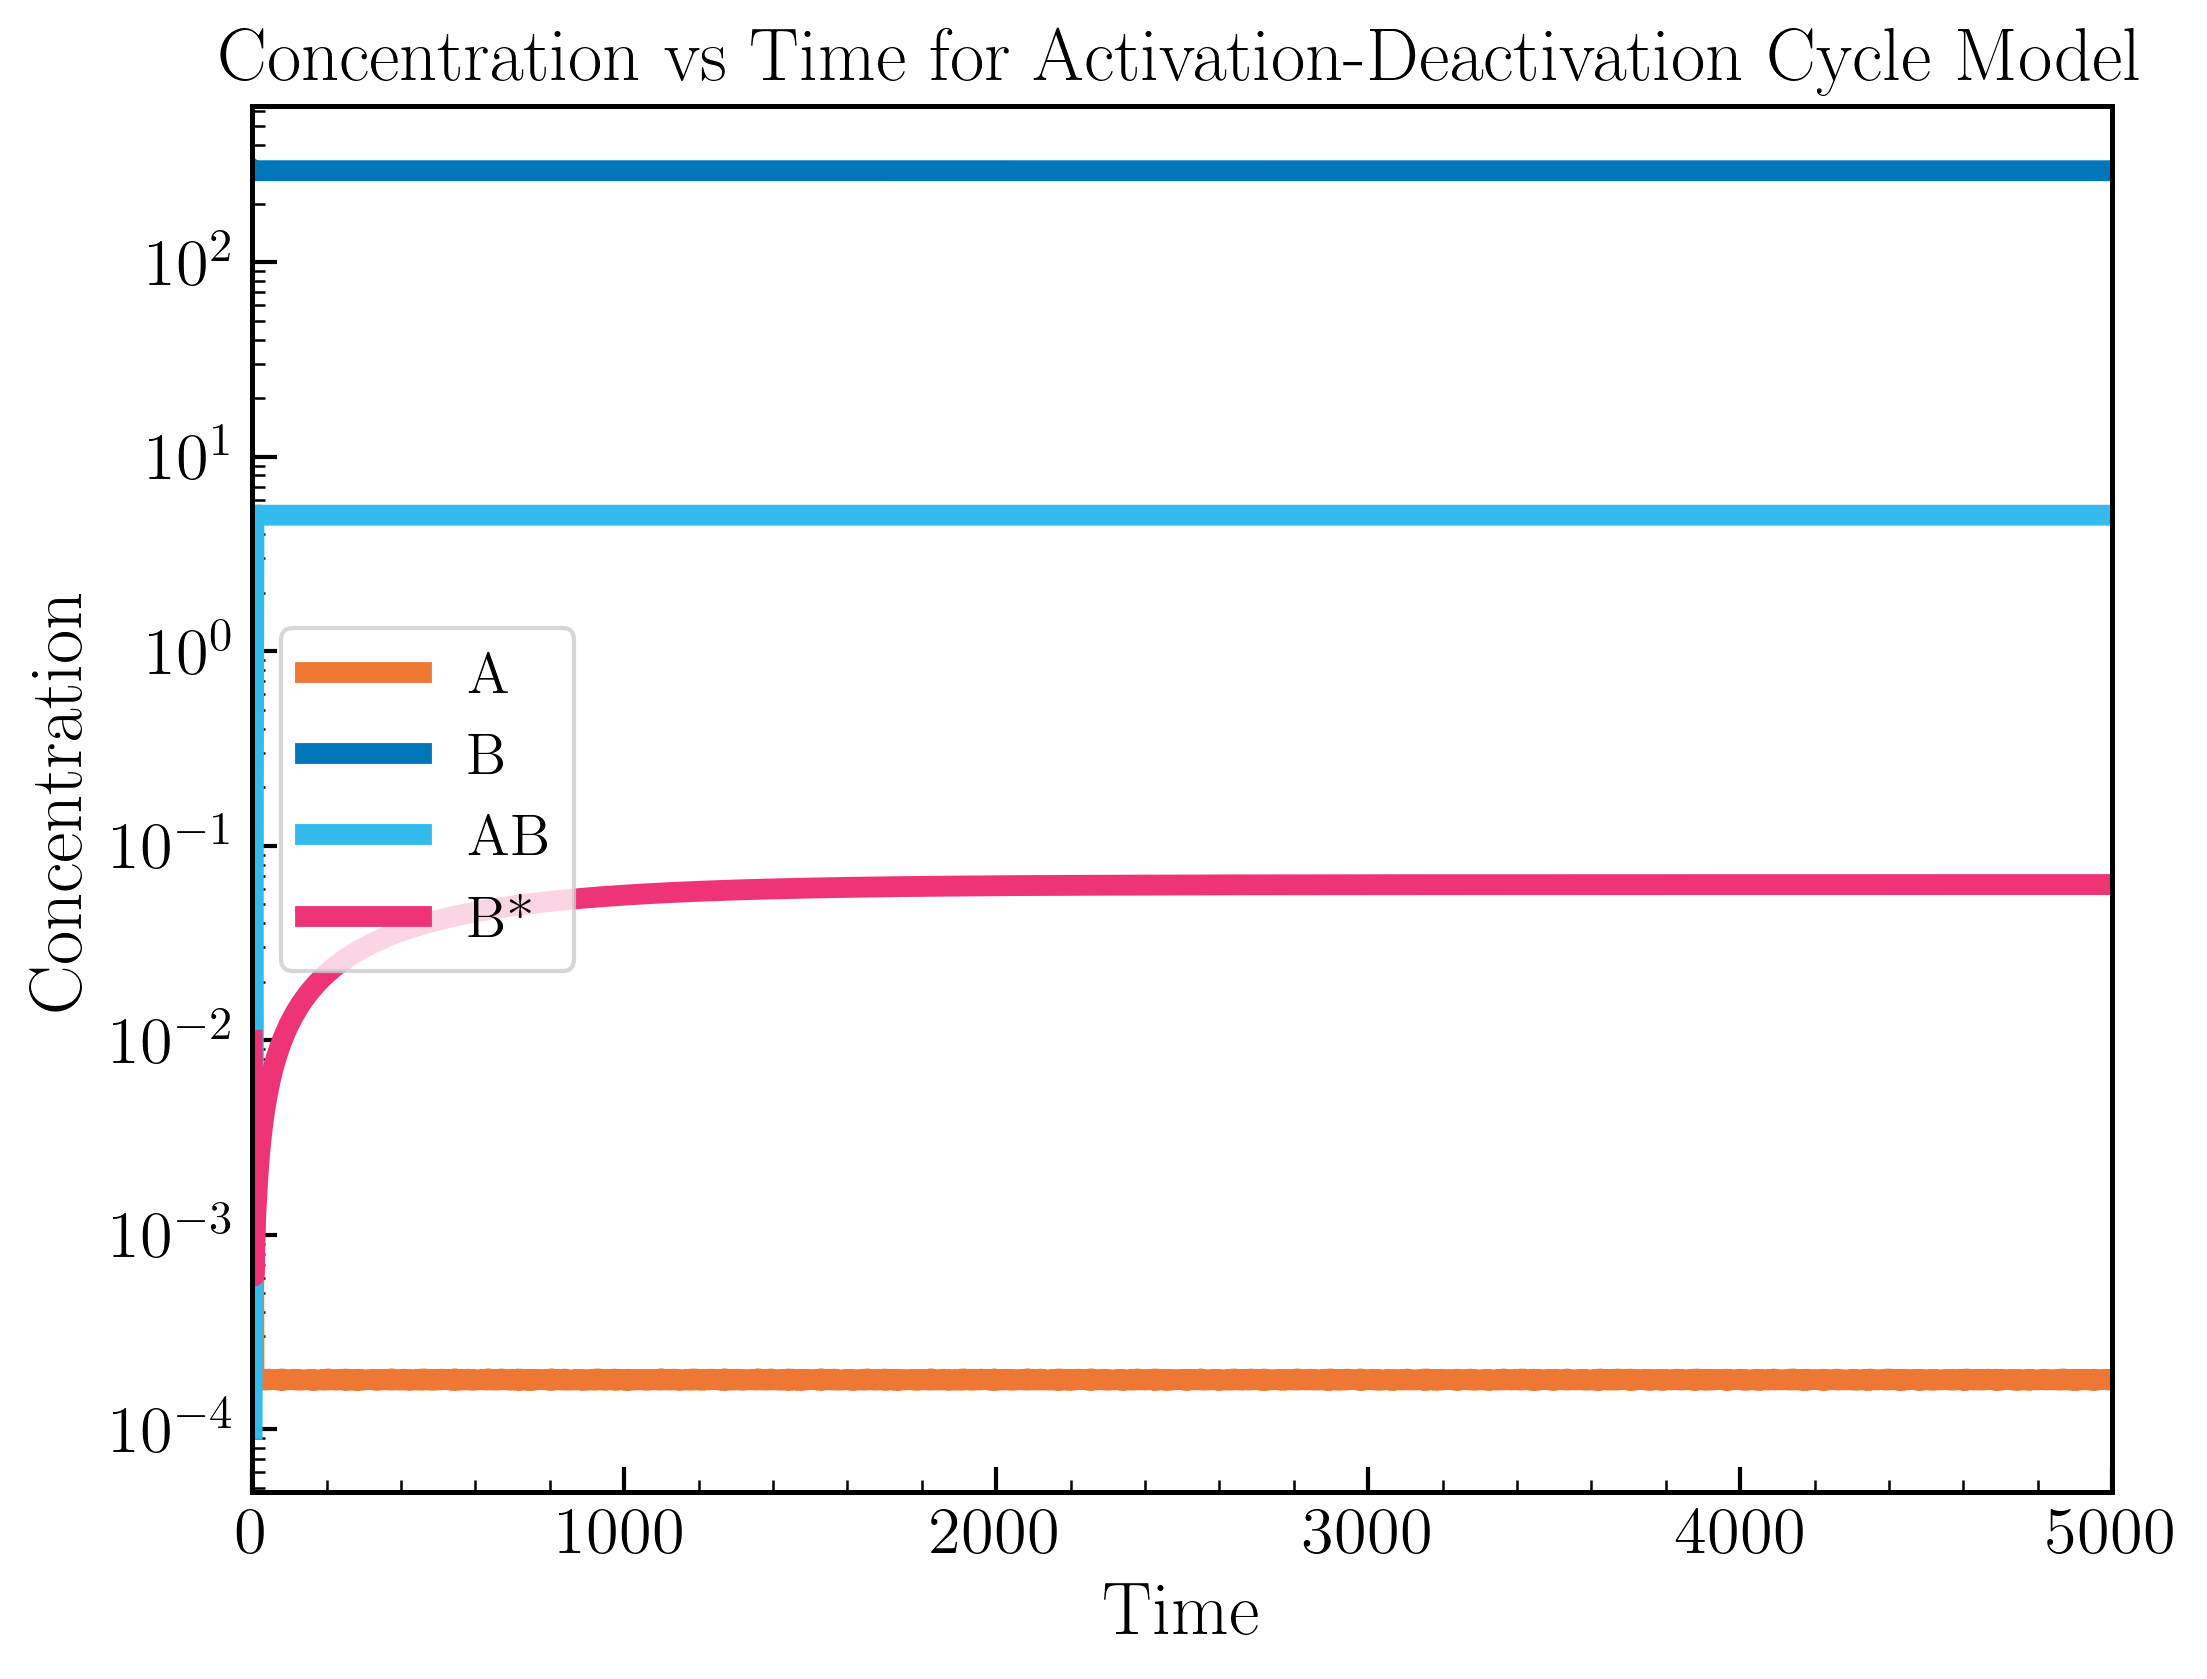

In [6]:
# Initial simulation to stablize the system
time_points_act_deact = np.linspace(0, 5000, 1001)
sol_act_deact = solve_complex_formation_act_deact_cycle(initial_conditions_act_deact,
                                                  time_points_act_deact,
                                                  params_act_deact_unstimulated)

plt.figure(figsize=(8, 6))
for i, c in enumerate(colors[:4]):
    plt.plot(time_points_act_deact, sol_act_deact.y[i], lw=5, color=c, label=f"S{i+1}")
# plt.plot(sol.t, sol.y.T)
# plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
plt.xlim(0, 5000)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for Activation-Deactivation Cycle Model')
plt.legend(['A', 'B', 'AB', 'B*'])
plt.show()

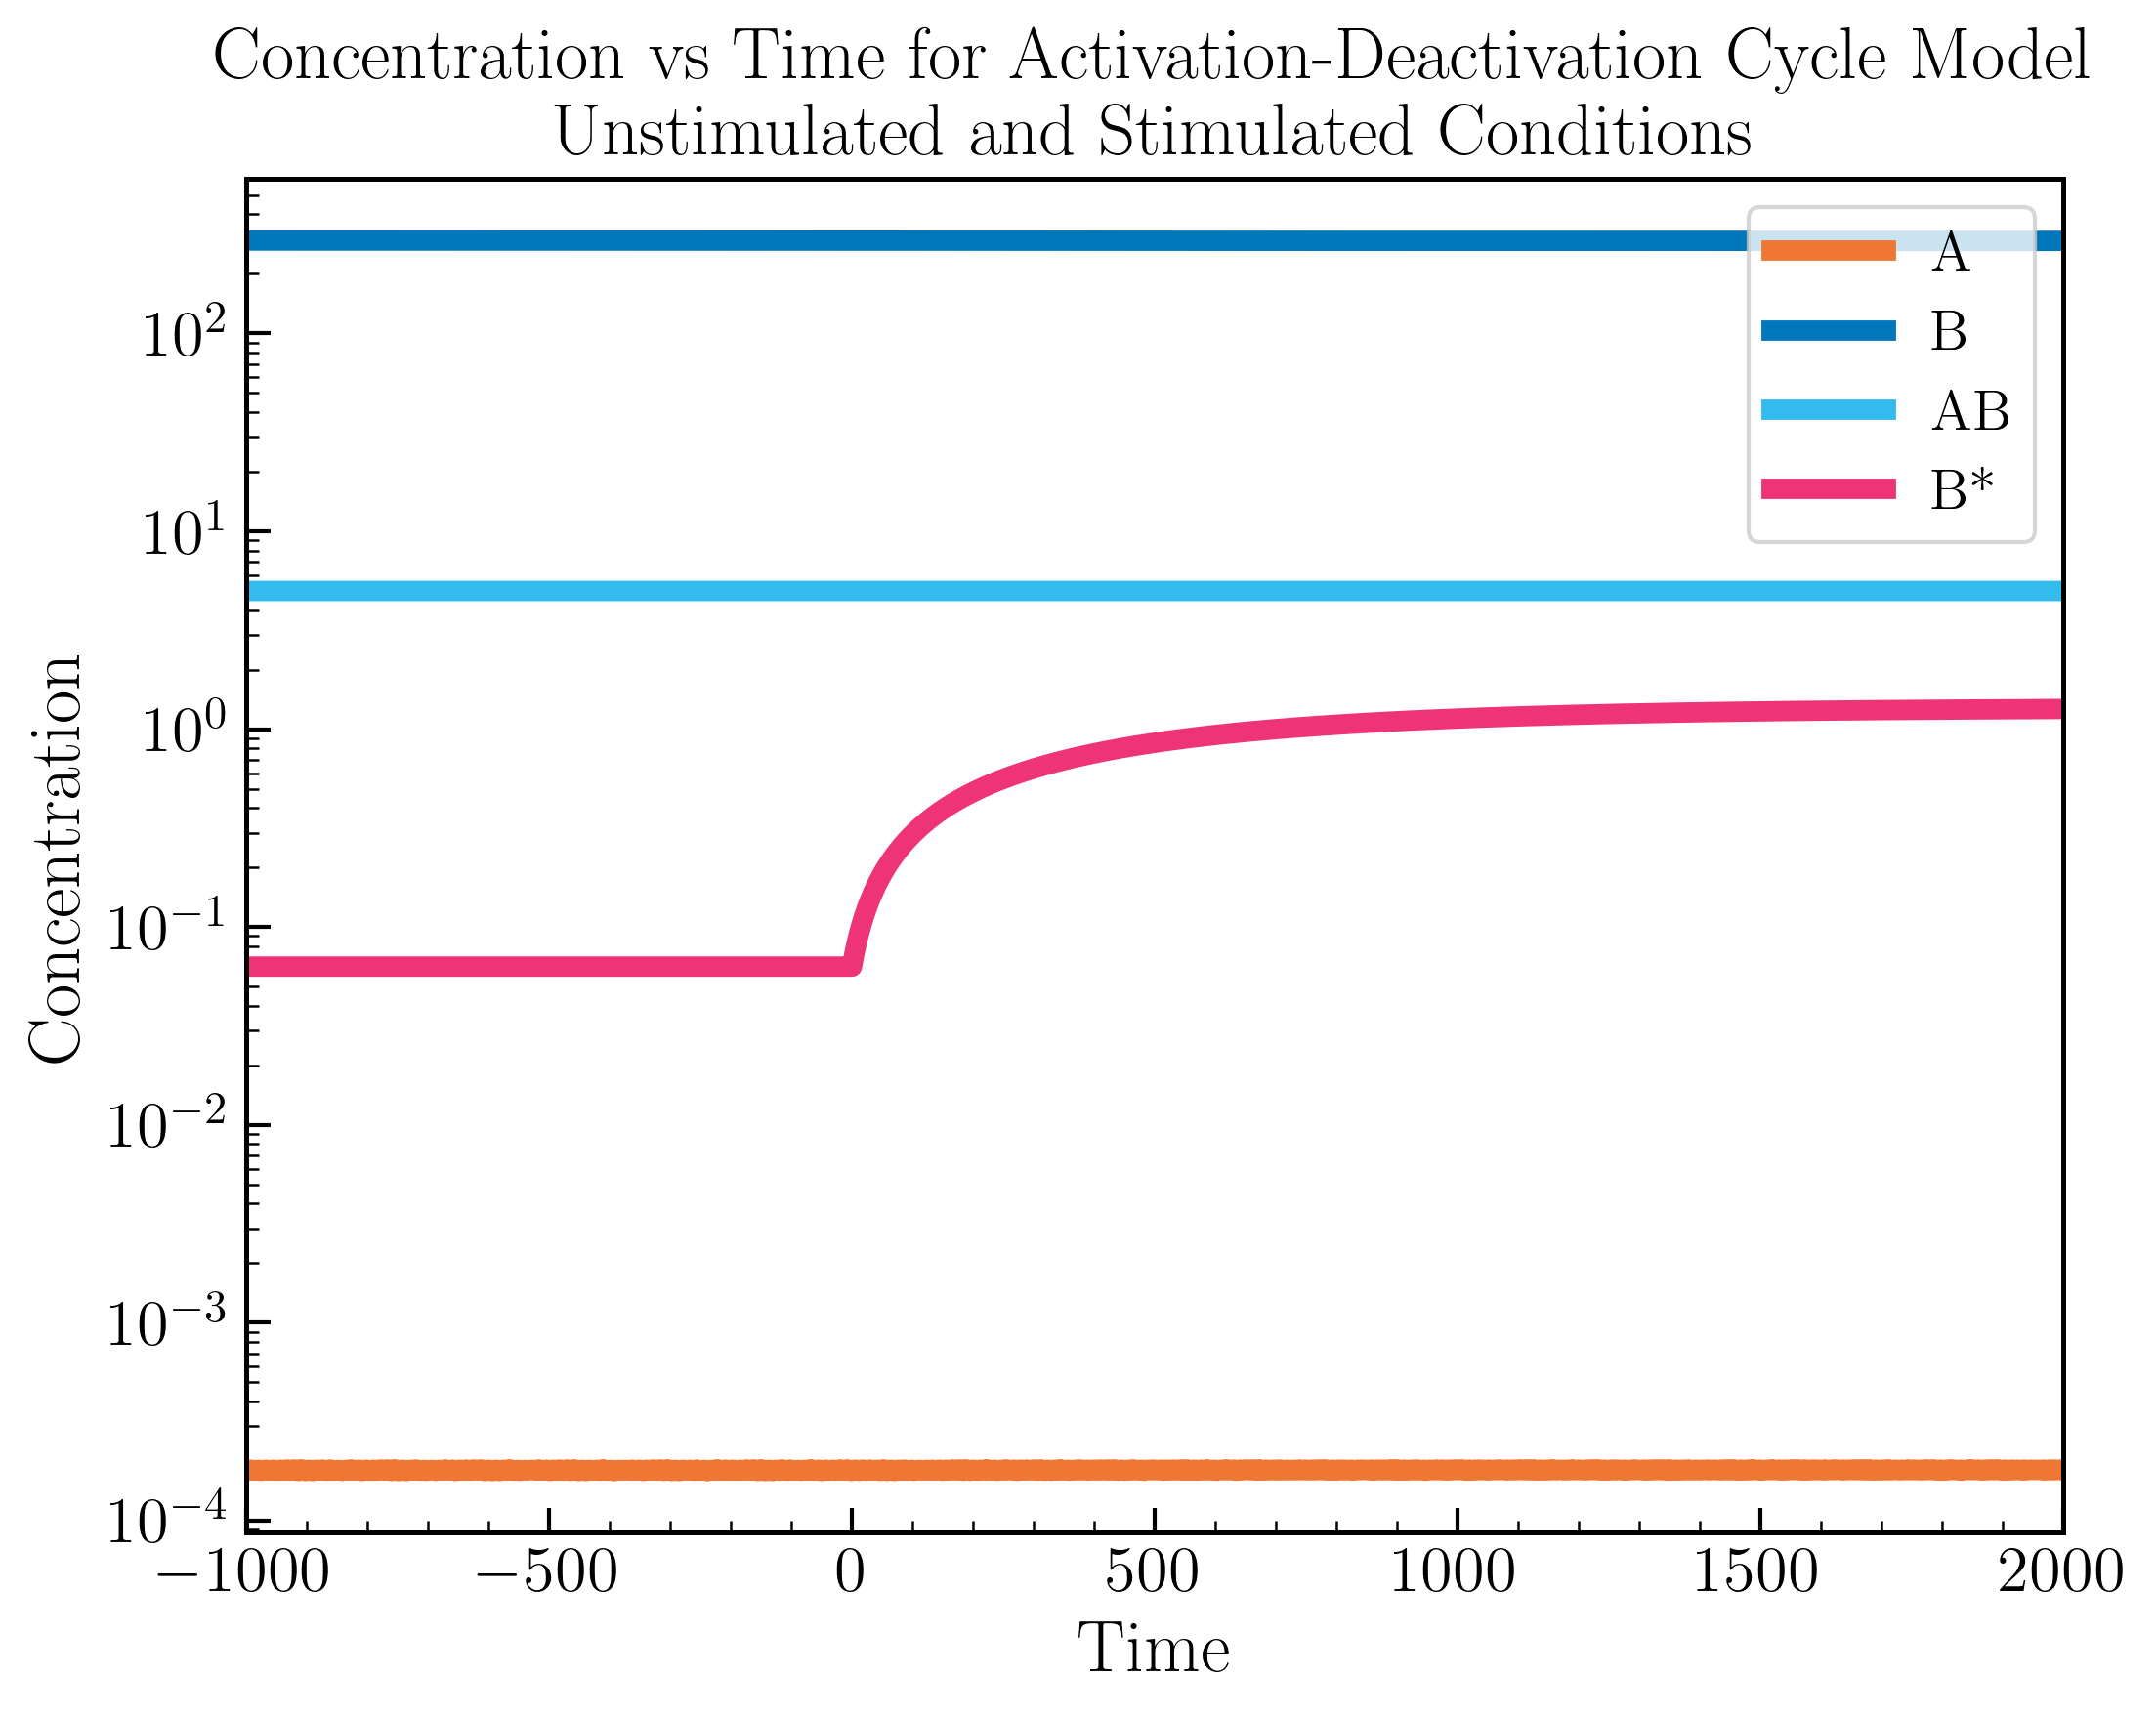

In [7]:
# Now, draw temporal dynamics for unstimulated conditions from t=[-1000, 0], and then stimulated conditions from t=[0, 2000]
time_1 = np.linspace(-1000, 0, 500)
time_2 = np.linspace(0, 2000, 1000)
sol_unstimulated = solve_complex_formation_act_deact_cycle(sol_act_deact.y[:, -1],
                                                  time_1,
                                                  params_act_deact_unstimulated)
sol_stimulated = solve_complex_formation_act_deact_cycle(sol_unstimulated.y[:, -1],
                                                  time_2,
                                                    params_act_deact_stimulated)
time_full = np.concatenate((time_1, time_2))
sol_full = np.hstack((sol_unstimulated.y, sol_stimulated.y))
plt.figure(figsize=(8, 6))
for i, c in enumerate(colors[:4]):
    plt.plot(time_full, sol_full[i], lw=5, color=c, label=f"S{i+1}")
plt.xlim(-1000, 2000)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for Activation-Deactivation Cycle Model\nUnstimulated and Stimulated Conditions')
plt.legend(['A', 'B', 'AB', 'B*'])
plt.show()

In [57]:
# Jacocbian calculation
j_matrix_un = numdifftools.Jacobian(lambda x: model_complex_formation_act_deact_cycle(x, params_act_deact_unstimulated),method="central")(sol_act_deact.y[:, -1])
signed_jacobian_un = np.sign(j_matrix_un)

j_matrix_st = numdifftools.Jacobian(lambda x: model_complex_formation_act_deact_cycle(x, params_act_deact_stimulated),method="central")(sol_unstimulated.y[:, -1])
signed_jacobian_st = np.sign(j_matrix_st)

In [58]:
print("Unstimulated conditions:")
print("Jacobian matrix:")
print(j_matrix_un)
print("Signed Jacobian matrix:")
print(signed_jacobian_un)

# print("\nStimulated conditions:")
# print("Jacobian matrix:")
# print(j_matrix_st)
# print("Signed Jacobian matrix:")
# print(signed_jacobian_st)

Unstimulated conditions:
Jacobian matrix:
[[-6.32897393e+00 -3.85693687e-06  2.27335000e-04  0.00000000e+00]
 [-5.57665958e+00 -3.87227773e-06  2.27335000e-04  2.13977829e-03]
 [ 6.32897393e+00  3.85693687e-06 -2.27335000e-04  0.00000000e+00]
 [-7.52314358e-01  1.53408584e-08  0.00000000e+00 -2.13977829e-03]]
Signed Jacobian matrix:
[[-1. -1.  1.  0.]
 [-1. -1.  1.  1.]
 [ 1.  1. -1.  0.]
 [-1.  1.  0. -1.]]


In [59]:
# Find loops
print("Unstimulated conditions:")
res_tab_complex = ld.find_loops_vset(model_complex_formation_act_deact_cycle,
                                     vset=[sol_act_deact.y[:, -1]],
                                     params=params_act_deact_unstimulated,
                                     max_num_loops=10)
print(res_tab_complex['loop_rep'][0].sort_values(by=['length','loop']))

# print("Stimulated conditions:")
# res_tab_complex_st = ld.find_loops_vset(model_complex_formation_act_deact_cycle,
#                                         vset=[sol_unstimulated.y[:, -1]],
#                                         params=params_act_deact_stimulated,
#                                         max_num_loops=10)
# print(res_tab_complex_st['loop_rep'][0].sort_values(by=['length','loop']))

Unstimulated conditions:
              loop  length  sign
8           (0, 0)       1    -1
9           (1, 1)       1    -1
0        (0, 1, 0)       2     1
2        (0, 2, 0)       2     1
6        (1, 2, 1)       2     1
7        (1, 3, 1)       2     1
1     (0, 1, 2, 0)       3    -1
3     (0, 2, 1, 0)       3    -1
4     (0, 3, 1, 0)       3     1
5  (0, 3, 1, 2, 0)       4    -1


In [60]:
print("\nLoop summary for unstimulated conditions:")
loop_list = ld.find_loops(j_matrix_un)
print(ld.loop_summary(loop_list))
# print("\nLoop summary for stimulated conditions:")
# loop_list_st = ld.find_loops(j_matrix_st)
# print(ld.loop_summary(loop_list_st))


Loop summary for unstimulated conditions:
length  1  2  3  4
total   4  4  3  1
neg     4  0  2  1
pos     0  4  1  0


In [61]:
# Search the time where loops structure changes (signed Jacobian changes)

for t, y in zip(time_full, sol_full.T):
    j_matrix_t = numdifftools.Jacobian(lambda x: model_complex_formation_act_deact_cycle(x, params_act_deact_unstimulated if t < 0 else params_act_deact_stimulated),method="central")(y)
    signed_jacobian_t = np.sign(j_matrix_t)
    if not np.array_equal(signed_jacobian_t, signed_jacobian_un if t < 0 else signed_jacobian_st):
        print(f"At time {t:.2f} after the stimulus, the signed Jacobian structure changes.")
        loop_list_t = ld.find_loops(j_matrix_t)
        print(f"Jacobian matrix at time {t:.2f}:")
        # Print number format as .2f for every number in the matrices but keeping the shape
        # print(np.array([[f"{x:.2f}" for x in row] for row in j_matrix_t]))
        print(j_matrix_t)
        print(f"Signed Jacobian matrix at time {t:.2f}:")
        print(signed_jacobian_t)
        print("Loop summary at this time:")
        print(ld.loop_summary(loop_list_t))
        break

At time 234.23 after the stimulus, the signed Jacobian structure changes.
Jacobian matrix at time 234.23:
[[-6.31881288e+00 -3.87396232e-06  2.27335000e-04  0.00000000e+00]
 [ 2.31710543e-02 -4.18173390e-06  2.27335000e-04  2.11311218e-03]
 [ 6.31881288e+00  3.87396232e-06 -2.27335000e-04  0.00000000e+00]
 [-6.34198393e+00  3.07771576e-07  0.00000000e+00 -2.11311218e-03]]
Signed Jacobian matrix at time 234.23:
[[-1. -1.  1.  0.]
 [ 1. -1.  1.  1.]
 [ 1.  1. -1.  0.]
 [-1.  1.  0. -1.]]
Loop summary at this time:
length  1  2  3  4
total   4  4  3  1
neg     4  1  1  1
pos     0  3  2  0


In [62]:
loop_list_t

,loop,length,sign
0,"(0, 1, 0)",2,-1
1,"(0, 1, 2, 0)",3,1
2,"(0, 2, 0)",2,1
3,"(0, 2, 1, 0)",3,-1
4,"(0, 3, 1, 0)",3,1
5,"(0, 3, 1, 2, 0)",4,-1
6,"(1, 2, 1)",2,1
7,"(1, 3, 1)",2,1
8,"(0, 0)",1,-1
9,"(1, 1)",1,-1


In [63]:
print("Unstimulated conditions:")
print(signed_jacobian_un)

Unstimulated conditions:
[[-1. -1.  1.  0.]
 [-1. -1.  1.  1.]
 [ 1.  1. -1.  0.]
 [-1.  1.  0. -1.]]


In [67]:
print("Stimulated conditions:")
print(signed_jacobian_t)

Stimulated conditions:
[[-1. -1.  1.  0.]
 [ 1. -1.  1.  1.]
 [ 1.  1. -1.  0.]
 [-1.  1.  0. -1.]]


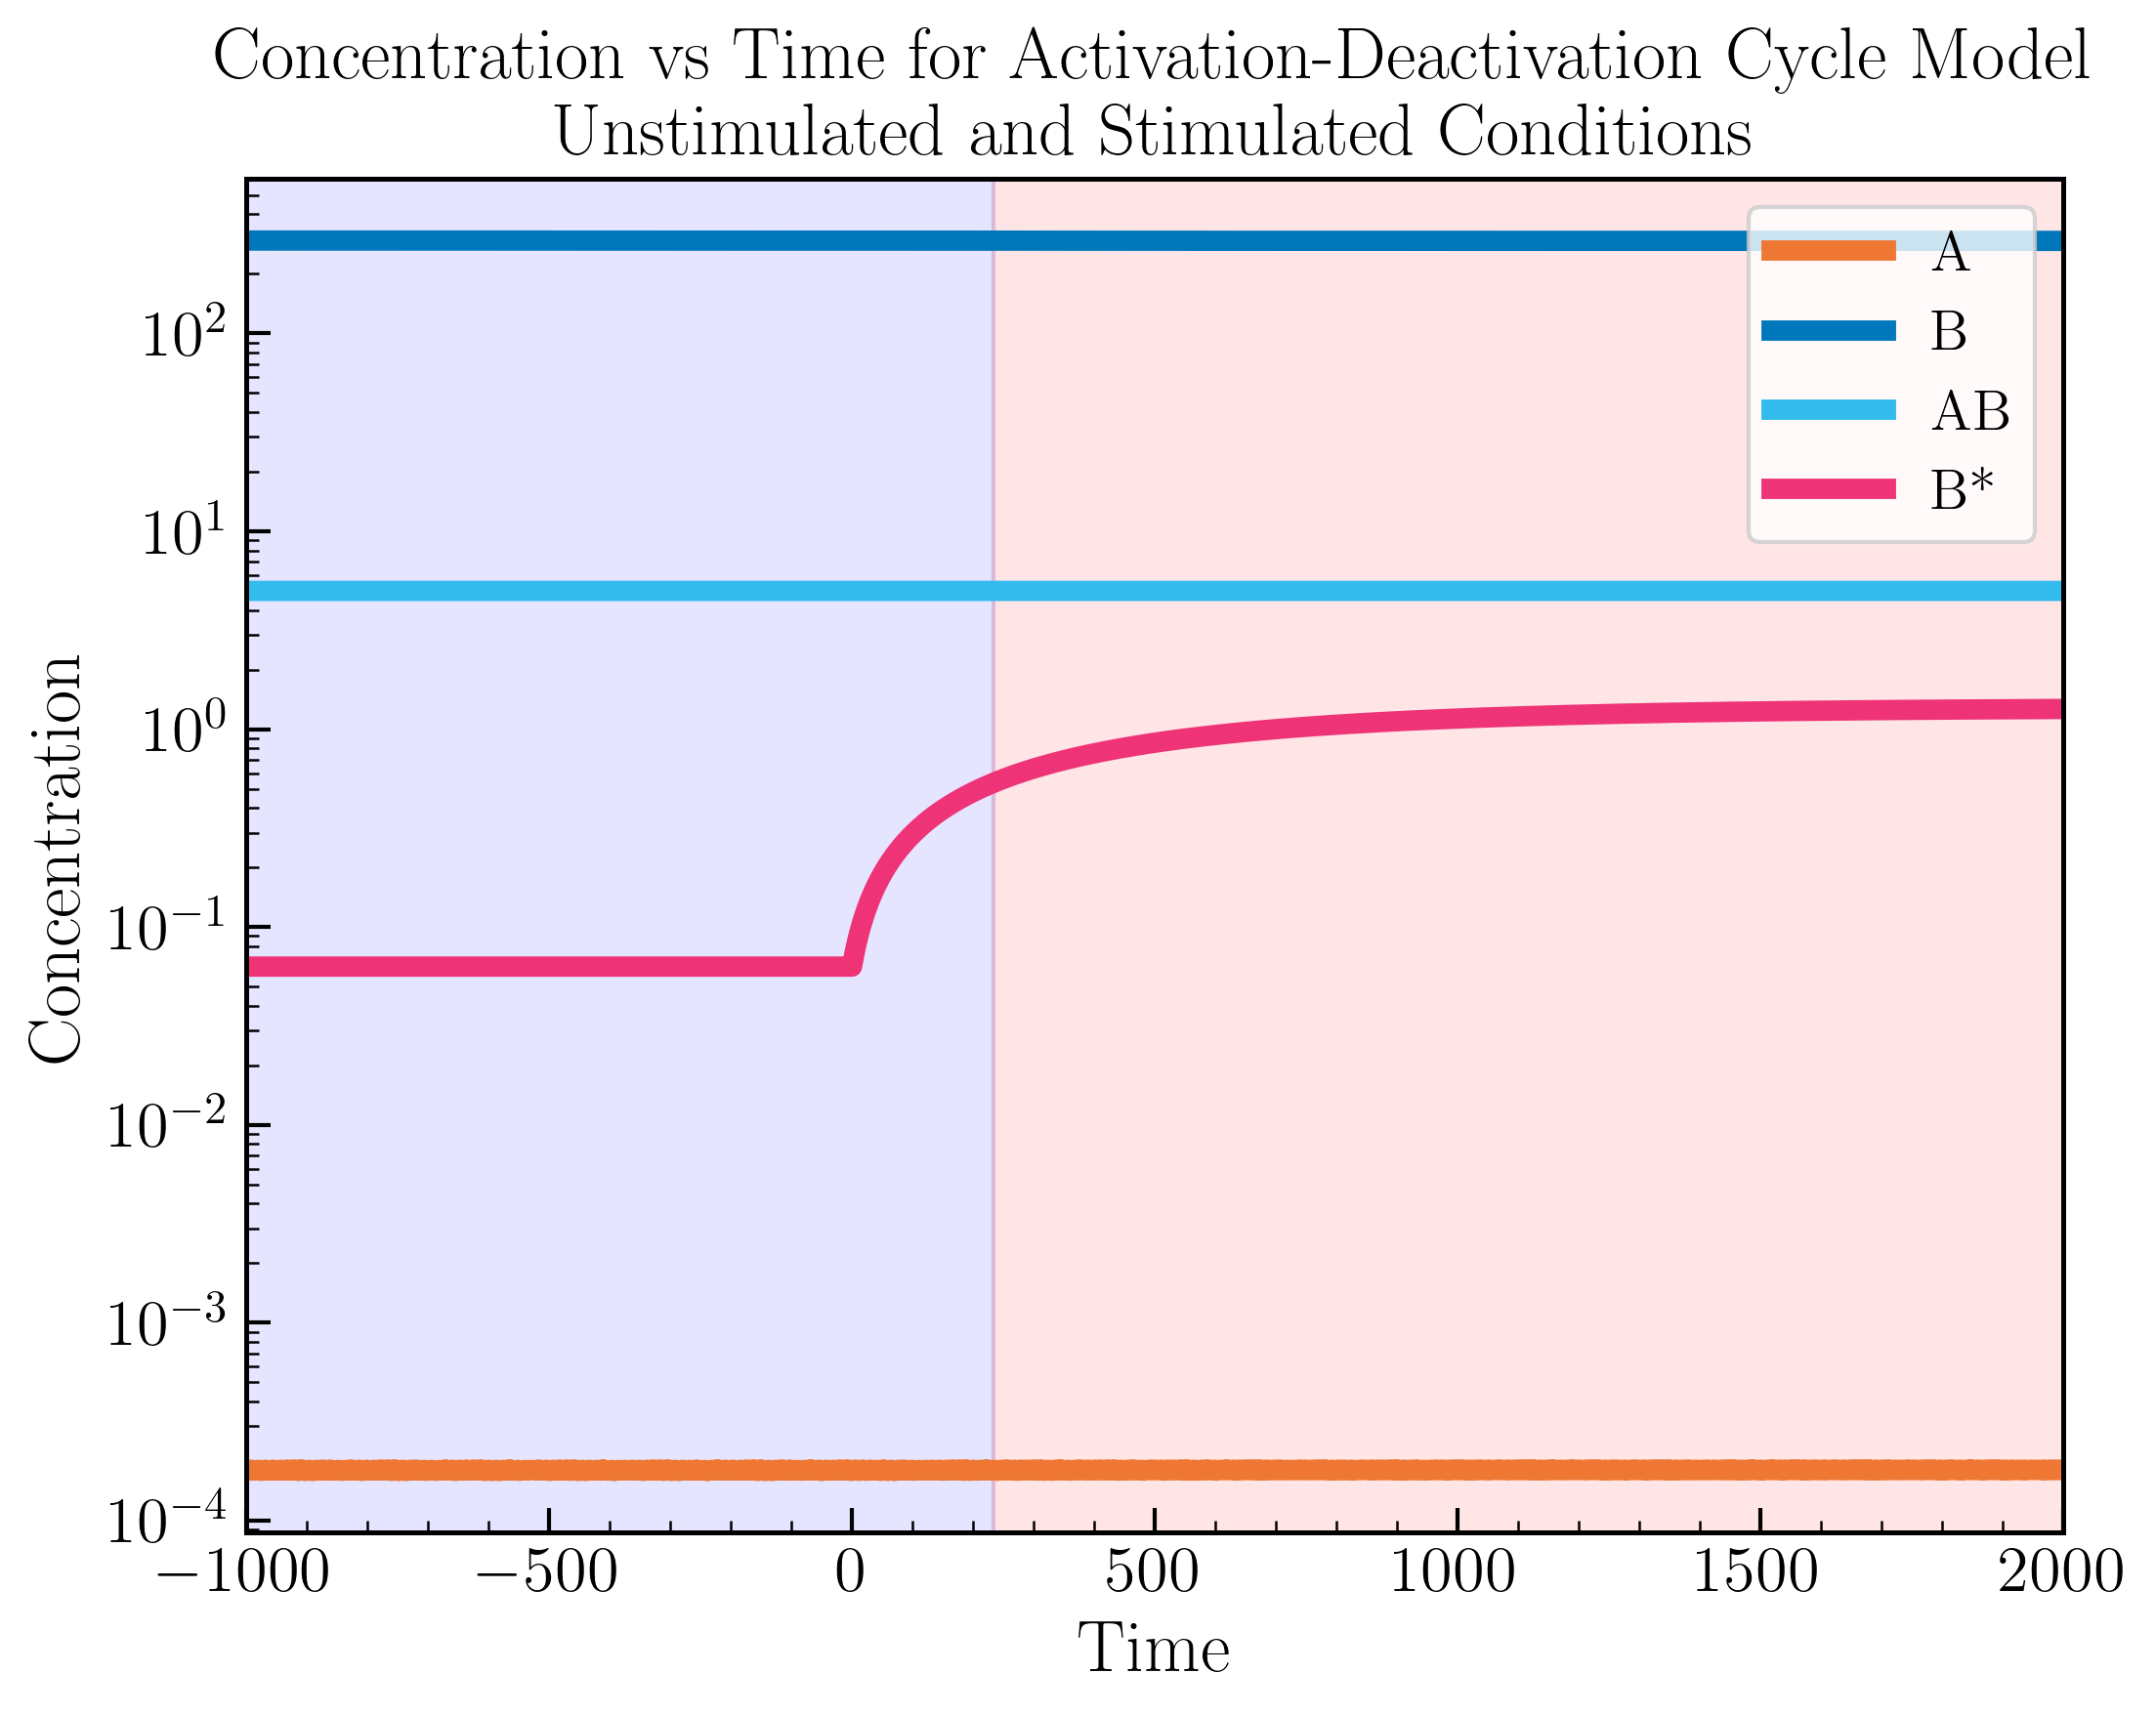

In [16]:
plt.figure(figsize=(8, 6))
for i, c in enumerate(colors[:4]):
    plt.plot(time_full, sol_full[i], lw=5, color=c, label=f"S{i+1}")
plt.xlim(-1000, 2000)

# Color the region before loop structure change and after
plt.axvspan(time_full[0], t, color='blue', alpha=0.1, label='Before loop structure change')
plt.axvspan(t, time_full[-1], color='red', alpha=0.1, label='After loop structure change')

plt.xlabel('Time')
plt.ylabel('Concentration')
plt.yscale('log')
plt.title('Concentration vs Time for Activation-Deactivation Cycle Model\nUnstimulated and Stimulated Conditions')
plt.legend(['A', 'B', 'AB', 'B*'])
plt.show()

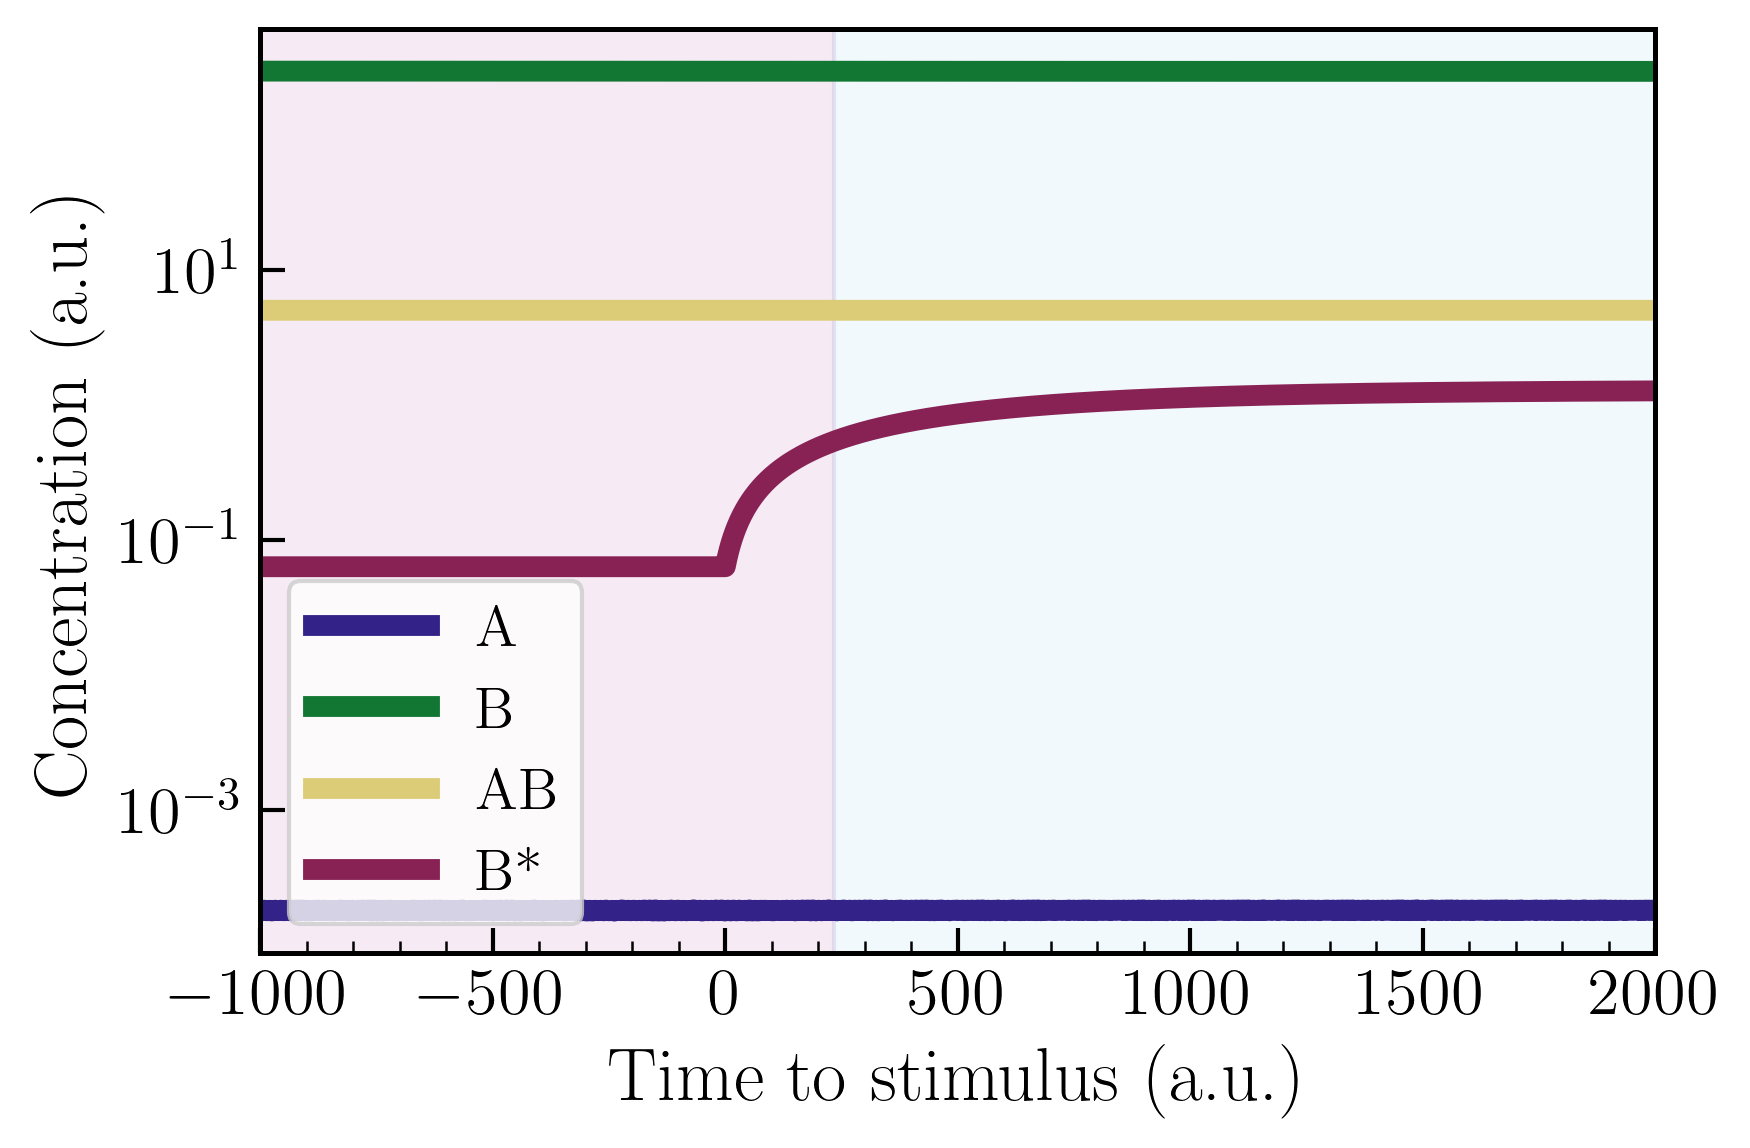

In [22]:
plt.figure(figsize=(6, 4))
for i, c in enumerate(colors_02[:4]):
    plt.plot(time_full, sol_full[i], lw=5, color=c, label=f"S{i+1}")
plt.xlim(-1000, 2000)

# Color the region before loop structure change and after
plt.axvspan(time_full[0], t, color=colors_02[4], alpha=0.1, label='Before loop structure change')
plt.axvspan(t, time_full[-1], color=colors_02[5], alpha=0.1, label='After loop structure change')

plt.xlabel('Time to stimulus (a.u.)')
plt.ylabel('Concentration (a.u.)')
plt.yscale('log')
# plt.title('Concentration vs Time for Activation-Deactivation Cycle Model\nUnstimulated and Stimulated Conditions')
plt.legend(['A', 'B', 'AB', 'B*'])
plt.savefig('img/model_3_complex_formation_extend.svg', bbox_inches='tight', dpi=300)
# plt.show()

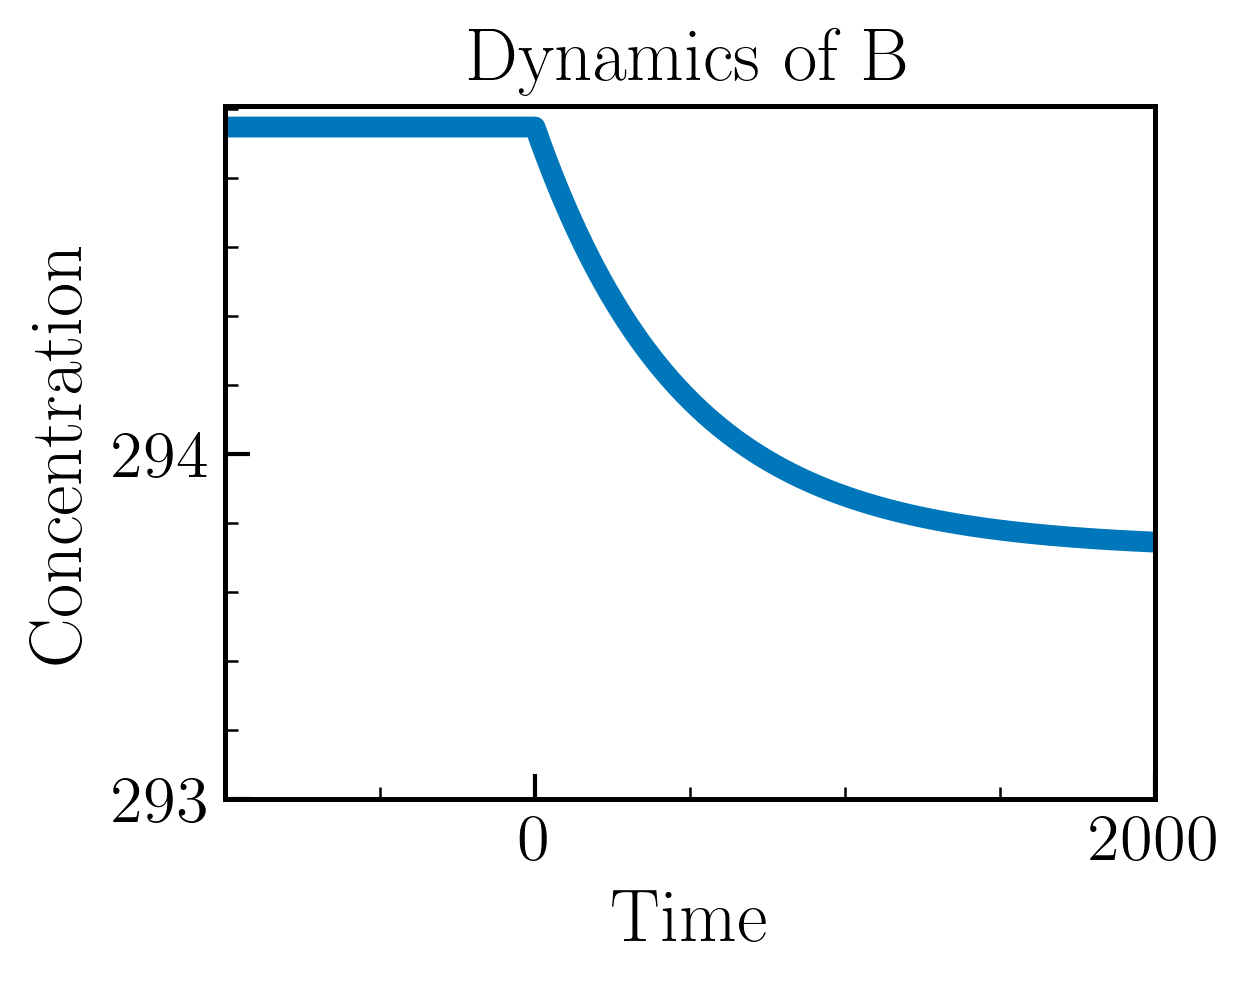

In [ ]:
# Zoom in around the perturbation point to see the dynamics more clearly (of only B)
plt.figure(figsize=(4, 3))
plt.plot(time_full, sol_full[1], lw=5, color=colors[1], label='B')
plt.xlim(-999, 2000)
# Show only 0 and 2000 on x-axis (but not -1000)
plt.xticks([0, 2000])
plt.yticks(np.arange(293, 295, 1))
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Dynamics of B')
# plt.legend()
plt.show()

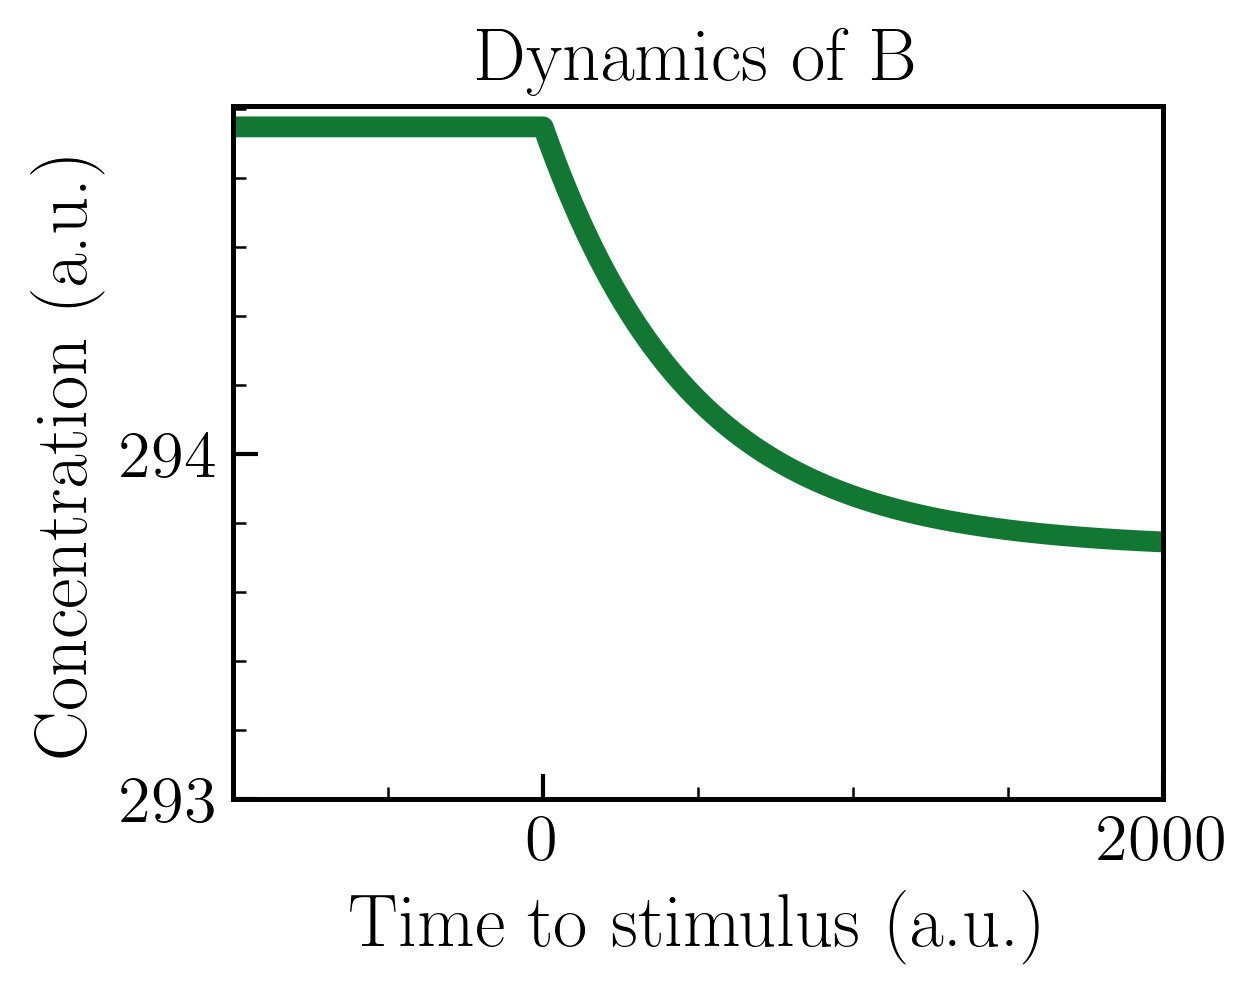

In [24]:
# Zoom in around the perturbation point to see the dynamics more clearly (of only B)
plt.figure(figsize=(4, 3))
plt.plot(time_full, sol_full[1], lw=5, color=colors_02[1], label='B')
plt.xlim(-999, 2000)
# Show only 0 and 2000 on x-axis (but not -1000)
plt.xticks([0, 2000])
plt.yticks(np.arange(293, 295, 1))
plt.xlabel('Time to stimulus (a.u.)')
plt.ylabel('Concentration (a.u.)')
plt.title('Dynamics of B')
plt.savefig('img/model_3_complex_formation_extend_B_zoom.svg', bbox_inches='tight', dpi=300)
# plt.legend()
plt.show()

## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [45]:
id_to_subject = {
    0: "A",
    1: "B",
    2: "AB",
    3: "B*"
}

df_un = pd.DataFrame(res_tab_complex['loop_rep'][0]).sort_values(by=['length','loop'])

df_un["loop_subject"] = df_un["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df_un

,loop,length,sign,loop_subject
8,"(0, 0)",1,-1,"(A, A)"
9,"(1, 1)",1,-1,"(B, B)"
0,"(0, 1, 0)",2,1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
6,"(1, 2, 1)",2,1,"(B, AB, B)"
7,"(1, 3, 1)",2,1,"(B, B*, B)"
1,"(0, 1, 2, 0)",3,-1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"
4,"(0, 3, 1, 0)",3,1,"(A, B*, B, A)"
5,"(0, 3, 1, 2, 0)",4,-1,"(A, B*, B, AB, A)"


In [46]:
id_to_subject = {
    0: "A",
    1: "B",
    2: "AB",
    3: "B*"
}

df_st = pd.DataFrame(loop_list_t).sort_values(by=['length','loop'])

df_st["loop_subject"] = df_st["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df_st

,loop,length,sign,loop_subject
8,"(0, 0)",1,-1,"(A, A)"
9,"(1, 1)",1,-1,"(B, B)"
10,"(2, 2)",1,-1,"(AB, AB)"
11,"(3, 3)",1,-1,"(B*, B*)"
0,"(0, 1, 0)",2,-1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
6,"(1, 2, 1)",2,1,"(B, AB, B)"
7,"(1, 3, 1)",2,1,"(B, B*, B)"
1,"(0, 1, 2, 0)",3,1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"


### 3.2. Represent regulation relationship from Jacobian matrix

In [ ]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

print("\nRegulation information for unstimulated conditions:")

regulation_info = pd.DataFrame(signed_jacobian_un, columns=[id_to_subject[i] for i in range(signed_jacobian_un.shape[1])], index=[id_to_subject[i] for i in range(signed_jacobian_un.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['from', 'to', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info


Regulation information for unstimulated conditions:


,from,to,regulation,regulation_words
0,A,A,-1.0,inhibition (negative)
1,A,B,-1.0,inhibition (negative)
2,A,AB,1.0,activation (positive)
3,A,B*,0.0,no regulation
4,B,A,-1.0,inhibition (negative)
5,B,B,-1.0,inhibition (negative)
6,B,AB,1.0,activation (positive)
7,B,B*,1.0,activation (positive)
8,AB,A,1.0,activation (positive)
9,AB,B,1.0,activation (positive)


##### Fix

In [65]:
signed_jacobian_un

array([[-1., -1.,  1.,  0.],
       [-1., -1.,  1.,  1.],
       [ 1.,  1., -1.,  0.],
       [-1.,  1.,  0., -1.]])

In [79]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

# Unstimulated conditions

signed_jacobian = signed_jacobian_un
labels = [id_to_subject[i] for i in range(signed_jacobian.shape[0])]
regulation_info_un = pd.DataFrame(signed_jacobian, columns=[labels[i] for i in range(signed_jacobian.shape[1])], index=[labels[i] for i in range(signed_jacobian.shape[0])])
regulation_info_un = regulation_info_un.stack().reset_index()
regulation_info_un.columns = ['to', 'from', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info_un['regulation_words'] = regulation_info_un['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info_un

,to,from,regulation,regulation_words
0,A,A,-1.0,inhibition (negative)
1,A,B,-1.0,inhibition (negative)
2,A,AB,1.0,activation (positive)
3,A,B*,0.0,no regulation
4,B,A,-1.0,inhibition (negative)
5,B,B,-1.0,inhibition (negative)
6,B,AB,1.0,activation (positive)
7,B,B*,1.0,activation (positive)
8,AB,A,1.0,activation (positive)
9,AB,B,1.0,activation (positive)


In [80]:
signed_jacobian_t

array([[-1., -1.,  1.,  0.],
       [ 1., -1.,  1.,  1.],
       [ 1.,  1., -1.,  0.],
       [-1.,  1.,  0., -1.]])

In [81]:
# Stimulated conditions

signed_jacobian = signed_jacobian_t
labels = [id_to_subject[i] for i in range(signed_jacobian.shape[0])]
regulation_info_st = pd.DataFrame(signed_jacobian, columns=[labels[i] for i in range(signed_jacobian.shape[1])], index=[labels[i] for i in range(signed_jacobian.shape[0])])
regulation_info_st = regulation_info_st.stack().reset_index()
regulation_info_st.columns = ['to', 'from', 'regulation']
# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info_st['regulation_words'] = regulation_info_st['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info_st

,to,from,regulation,regulation_words
0,A,A,-1.0,inhibition (negative)
1,A,B,-1.0,inhibition (negative)
2,A,AB,1.0,activation (positive)
3,A,B*,0.0,no regulation
4,B,A,1.0,activation (positive)
5,B,B,-1.0,inhibition (negative)
6,B,AB,1.0,activation (positive)
7,B,B*,1.0,activation (positive)
8,AB,A,1.0,activation (positive)
9,AB,B,1.0,activation (positive)


In [82]:
# Extract index from df
df_un['index'] = df_un.index
df_st['index'] = df_st.index

In [91]:
select_loop = 0
loop_data = df_un[df_un['index'] == select_loop]
loop_data

interaction_list = []
for _, row in loop_data.iterrows():
    loop = row['loop']
    for i in range(len(loop)):
        from_id = loop[i]
        to_id = loop[(i + 1) % len(loop)]  # Wrap around to create a loop
        regulation = signed_jacobian_un[to_id, from_id]
        interaction_list.append({
            'from': id_to_subject[from_id],
            'to': id_to_subject[to_id],
            'regulation': regulation,
            'regulation_words': regulation_info_un[
                (regulation_info_un['from'] == id_to_subject[from_id]) &
                (regulation_info_un['to'] == id_to_subject[to_id])
            ]['regulation_words'].values[0]
        })
interaction_df = pd.DataFrame(interaction_list)
interaction_df

,from,to,regulation,regulation_words
0,A,B,-1.0,inhibition (negative)
1,B,A,-1.0,inhibition (negative)
2,A,A,-1.0,inhibition (negative)


In [92]:
select_loop = 0
loop_data = df_st[df_st['index'] == select_loop]
loop_data
interaction_list = []
for _, row in loop_data.iterrows():
    loop = row['loop']
    for i in range(len(loop)):
        from_id = loop[i]
        to_id = loop[(i + 1) % len(loop)]  # Wrap around to create a loop
        regulation = signed_jacobian_t[to_id, from_id]
        interaction_list.append({
            'from': id_to_subject[from_id],
            'to': id_to_subject[to_id],
            'regulation': regulation,
            'regulation_words': regulation_info_st[
                (regulation_info_st['from'] == id_to_subject[from_id]) &
                (regulation_info_st['to'] == id_to_subject[to_id])
            ]['regulation_words'].values[0]
        })
interaction_df = pd.DataFrame(interaction_list)
interaction_df

,from,to,regulation,regulation_words
0,A,B,1.0,activation (positive)
1,B,A,-1.0,inhibition (negative)
2,A,A,-1.0,inhibition (negative)


### 3.3. Loop Summary in more detail

In [ ]:
# Given dataframe from 3.1 named `df`
df

,loop,length,sign,loop_subject
8,"(0, 0)",1,-1,"(A, A)"
9,"(1, 1)",1,-1,"(B, B)"
0,"(0, 1, 0)",2,1,"(A, B, A)"
2,"(0, 2, 0)",2,1,"(A, AB, A)"
6,"(1, 2, 1)",2,1,"(B, AB, B)"
7,"(1, 3, 1)",2,1,"(B, B*, B)"
1,"(0, 1, 2, 0)",3,-1,"(A, B, AB, A)"
3,"(0, 2, 1, 0)",3,-1,"(A, AB, B, A)"
4,"(0, 3, 1, 0)",3,1,"(A, B*, B, A)"
5,"(0, 3, 1, 2, 0)",4,-1,"(A, B*, B, AB, A)"


In [ ]:
# Loop summary (A different way)
loop_summary = df.groupby('length').agg(
    num_loops=('loop', 'count'),
    loops=('loop_subject', lambda x: list(x))
).reset_index()
loop_summary

,length,num_loops,loops
0,1,2,"[(A, A), (B, B)]"
1,2,4,"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]"
2,3,3,"[(A, B, AB, A), (A, AB, B, A), (A, B*, B, A)]"
3,4,1,"[(A, B*, B, AB, A)]"


In [ ]:
# make an extended loop summary with added information: 'num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative'
# Loop positive if sign is positive, negative if sign is negative
def count_loop_types(loop_subjects, regulation_info):
    num_positive = 0
    num_negative = 0
    loops_positive = []
    loops_negative = []
    
    for loop in loop_subjects:
        sign = 1
        for i in range(len(loop)):
            from_node = loop[i]
            to_node = loop[(i + 1) % len(loop)]
            regulation = regulation_info[
                (regulation_info['from'] == from_node) & 
                (regulation_info['to'] == to_node)
            ]['regulation'].values[0]
            sign *= regulation
        if sign > 0:
            num_positive += 1
            loops_positive.append(loop)
        else:
            num_negative += 1
            loops_negative.append(loop)
    return num_positive, num_negative, loops_positive, loops_negative
loop_summary_extended = loop_summary.copy()
loop_summary_extended[['num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative']] = loop_summary_extended['loops'].apply(
    lambda x: pd.Series(count_loop_types(x, regulation_info))
)
loop_summary_extended

,length,num_loops,loops,num_loops_positive,num_loops_negative,loops_positive,loops_negative
0,1,2,"[(A, A), (B, B)]",2,0,"[(A, A), (B, B)]",[]
1,2,4,"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]",0,4,[],"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]"
2,3,3,"[(A, B, AB, A), (A, AB, B, A), (A, B*, B, A)]",2,1,"[(A, B, AB, A), (A, AB, B, A)]","[(A, B*, B, A)]"
3,4,1,"[(A, B*, B, AB, A)]",0,1,[],"[(A, B*, B, AB, A)]"


In [ ]:
# Columns can be rearranged based on preference
cols = ['length', 'num_loops', 'num_loops_positive', 'num_loops_negative', 'loops', 'loops_positive', 'loops_negative']
loop_summary_extended = loop_summary_extended[cols]
loop_summary_extended

,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
0,1,2,2,0,"[(A, A), (B, B)]","[(A, A), (B, B)]",[]
1,2,4,0,4,"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]",[],"[(A, B, A), (A, AB, A), (B, AB, B), (B, B*, B)]"
2,3,3,2,1,"[(A, B, AB, A), (A, AB, B, A), (A, B*, B, A)]","[(A, B, AB, A), (A, AB, B, A)]","[(A, B*, B, A)]"
3,4,1,0,1,"[(A, B*, B, AB, A)]",[],"[(A, B*, B, AB, A)]"
